# Superstore Sales — Phase 1: Data Cleaning & Preprocessing


## 0. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Load the raw data

In [5]:
df = pd.read_csv(r'D:\data sets\Superstore Sales Analysis\sample_-_superstore.csv')

print('Shape:', df.shape)          # (rows, columns)
df.head()

Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
# Quick structural overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

## 2. Missing values

We check every column for NaNs and decide how to handle them.

In [8]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values in any column.')

No missing values in any column.


**Decision:** This version of the dataset has **no missing values** in any column.


## 3. Duplicate rows

In [11]:
dupes = df.duplicated().sum()
print('Duplicate rows found:', dupes)

# Remove them if any exist (no-op here since dupes == 0, but kept for robustness)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after de-duplication:', df.shape)

Duplicate rows found: 0
Shape after de-duplication: (10194, 21)


**Decision:** No duplicate rows exist. The `drop_duplicates()` call is kept so the
pipeline stays correct if the source file is ever refreshed with dirtier data.

## 4. Data type correction — dates

`Order Date` and `Ship Date` load as strings. We convert them to real `datetime`
objects so we can do date arithmetic and extract months later.




In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

print(df[['Order Date', 'Ship Date']].dtypes)
print('Order Date range:', df['Order Date'].min().date(), '->', df['Order Date'].max().date())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
Order Date range: 2023-01-03 -> 2026-12-30


## 5. Feature engineering

Two new columns the analysts will need:

- **Shipping Duration** — days between order and shipment (`Ship Date - Order Date`).
- **Profit Margin** — profitability per dollar of sales (`Profit / Sales`).

In [16]:
# Shipping Duration in whole days
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit Margin as a ratio (multiply by 100 later if a percentage is wanted)
df['Profit Margin'] = df['Profit'] / df['Sales']

# Sanity checks
print('Shipping Duration -> min:', df['Shipping Duration'].min(),
      '| max:', df['Shipping Duration'].max(),
      '| mean:', round(df['Shipping Duration'].mean(), 2))
print('Negative shipping durations (should be 0):', (df['Shipping Duration'] < 0).sum())
print('Rows with Sales == 0 (would break margin):', (df['Sales'] == 0).sum())
print('Profit Margin NaN/inf:', df['Profit Margin'].isna().sum(),
      np.isinf(df['Profit Margin']).sum())

Shipping Duration -> min: 0 | max: 11 | mean: 3.96
Negative shipping durations (should be 0): 0
Rows with Sales == 0 (would break margin): 0
Profit Margin NaN/inf: 0 0


**Note:** all shipping durations are non-negative (no data-entry errors), and no
row has `Sales == 0`, so Profit Margin has no divide-by-zero / infinity issues.

## 6. Final check & export

The cleaned DataFrame is saved to `superstore_clean.csv`.

In [19]:
print('Final shape:', df.shape)
df[['Order Date', 'Ship Date', 'Shipping Duration',
    'Sales', 'Profit', 'Profit Margin']].head()

Final shape: (10194, 23)


,Order Date,Ship Date,Shipping Duration,Sales,Profit,Profit Margin
0,2023-01-03,2023-01-07,4,16.448,5.5512,0.3375
1,2023-01-04,2023-01-08,4,3.540,-5.4870,-1.5500
2,2023-01-04,2023-01-08,4,11.784,4.2717,0.3625
3,2023-01-04,2023-01-08,4,272.736,-64.7748,-0.2375
4,2023-01-05,2023-01-12,7,19.536,4.8840,0.2500


In [20]:
#df.to_csv('superstore_clean.csv', index=False)
#print('Saved cleaned dataset -> superstore_clean.csv')

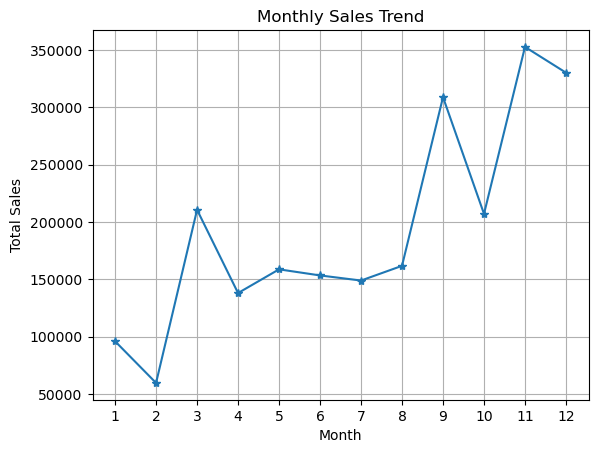

In [34]:
monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

plt.plot(monthly_sales.index, monthly_sales.values, marker='*')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()

In [37]:
total_sales = (
    df.groupby(["Category", "Sub-Category"], as_index=False)["Sales"]
      .sum()
)

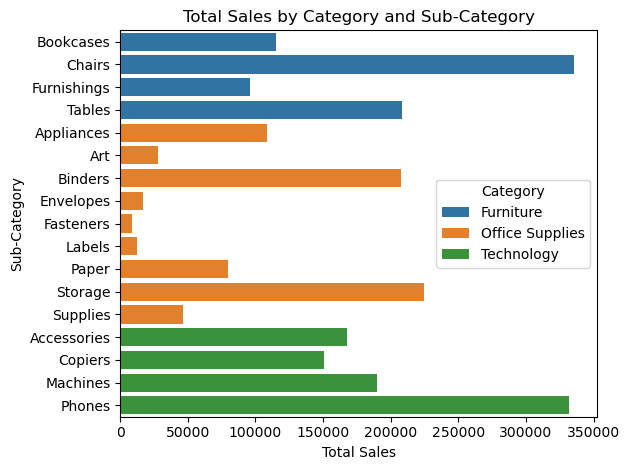

In [39]:
sns.barplot(
    data=total_sales,
    x="Sales",
    y="Sub-Category",
    hue="Category"
)

plt.title("Total Sales by Category and Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.legend(title="Category")
plt.tight_layout()

plt.show()

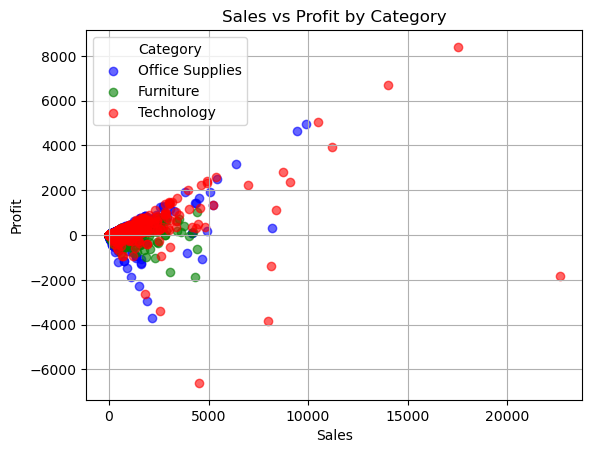

In [41]:
categories = df["Category"].unique()
colors = ["blue", "green", "red"]

for category, color in zip(categories, colors):
    data = df[df["Category"] == category]

    plt.scatter(
        data["Sales"],
        data["Profit"],
        color=color,
        label=category,
        alpha=0.6
    )

plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend(title="Category")
plt.grid(True)

